## Introduction


### Dataset
The dataset used for this analysis is the "Fake News Classification" dataset from Kaggle. It contains news articles labeled as "fake" or "real". The dataset includes the following columns:
- `id`: Unique identifier for each news article
- `title`: The title of the news article
- `text`: The full text of the news article
- `label`: The label indicating whether the news is "fake" (0) or "real" (1)

### Objective
The objective of this analysis is to build a machine learning model that can classify news articles as fake or real based on their content.
We will perform the following steps:
1. Data Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Building
5. Model Evaluation
6. Conclusion

### Data Preprocessing

In [ ]:
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import joblib

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import pandas as pd

from spellchecker import SpellChecker
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import lightgbm as lgb


In [2]:
df = pd.read_csv("WELFake_Dataset.csv")

# remove data with text null
df = df[["title", "text", "label"]].dropna(subset=['text'])
# substitue null values with "" in title column
df['title'] = df['title'].fillna("")

### Stylometric Feature Engineering
This section focuses on extracting stylometric features from the news articles to enhance the model's ability to distinguish between fake and real news. Stylometric features are derived from the writing style of the text and can provide insights into the authenticity of the news articles.

In [3]:
# add column with the length of the text
df['text_length'] = df['text'].apply(len)
# add column with ratio of exclamation point and question mark in the text
df['text_exclamation_ratio'] = df['text'].apply(lambda x: (x.count('!') + x.count('?')) / len(x) if len(x) > 0 else 0)
# add column with uppercase chars ratio in the title
df['title_uppercase_ratio'] = df['title'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
# add column with ratio of exclamation point and question mark in the title
df['title_exclamation_ratio'] = df['title'].apply(lambda x: (x.count('!') + x.count('?')) / len(x) if len(x) > 0 else 0)

In [4]:
# here we create a new column 'full_text' that combines the 'title' and 'text' columns. This will allow us to analyze the entire content of the news articles when extracting stylometric features.
df['full_text'] = df['title'] + " " + df['text']

### Linguistic Integrity and Noise Removal
First we will define a function to calculate spelling errors ratio, which is a stylometric feature that can help in distinguishing between fake and real news articles. The function will use the `pyspellchecker` library to identify misspelled words in the text and calculate the ratio of spelling errors to total words.

After that, we will apply this function to the dataset to create a new feature called `spelling_errors_ratio`. This feature will be added to our stylometric features for further analysis and modeling.

Finally, we will clean the text data by removing HTML tags, URLs, and non-alphanumeric characters. This will help in reducing noise and improving the quality of the textual features for our model.

In [8]:
spell = SpellChecker()

def count_spelling_errors(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0
    # Divide into words
    words = re.findall(r'\b\w+\b', text.lower())
    if len(words) == 0:
        return 0
    
    misspelled = spell.unknown(words)
    return len(misspelled) / len(words)


print("Calculating...")
df['spelling_errors_ratio'] = df['full_text'].apply(count_spelling_errors)
print("Done!")

Calculating...
Done!


In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

nltk.download('wordnet')
nltk.download('omw-1.4')


stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

custom_stopwords = [
    'said', 'mr', 'mrs', 'just', 'like', 'new', 'year', 'time', 'also', 'would', 'one',
    'trump', 'clinton', 'hillary', 'obama', 'donald', 'barack', 'president', 
    'state', 'states', 'government', 'house', 'white', 'republican', 'democrat', 'american',
    'reuters', 'washington', 'featured', 'image', 'images', 'getty', 'pic', 
    'twitter', 'com', 'via', 'fox', 'news', 'video', 'youtube'
]
stop_words.update(custom_stopwords)

def clean_text(text):
    # 1. Noise Removal (HTML, URLs, non-alphanumeric)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    # 2. Case Folding
    text = text.lower()
    
    # 3. Tokenization 
    tokens = word_tokenize(text)
    
    # 4. Stopword Elimination
    filtered_tokens = [w for w in tokens if w not in stop_words]

    # 5. Lemmatization
    lemmas = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    
    return " ".join(lemmas)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Advancia\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Advancia\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Advancia\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Advancia\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Advancia\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [10]:
df["cleaned_text"] = df["full_text"].apply(clean_text)

### Vectorization and Scaling
Here the idea is to create two separate pipelines: one for the textual features (TF-IDF) and one for the stylometric features (StandardScaler). Then we will combine them into a single feature set for modeling.

Steps:
1. Define Xs and y, one X is the textual features (the cleaned text) and the other X is the stylometric features (the engineered features).
2. Split the dataset into training and test sets (80% training, 20% test).
3. Apply TF-IDF vectorization to the textual features (fit on train, transform on test).
4. Apply StandardScaler to the stylometric features (fit on train, transform on test).
5. Combine the TF-IDF features and the scaled stylometric features into a single feature set for both training and test data.

This process is useful to avoid DATA LEAKAGE, ensuring that the transformations are only learned from the training data and then applied to the test data.

In [ ]:
# 1. Define features (X) and target (y)
X_stylometric = df[['text_length', 'title_uppercase_ratio', 
                    'title_exclamation_ratio', 'text_exclamation_ratio', 
                    'spelling_errors_ratio']]
X_text = df['cleaned_text']
y = df['label']

# 2. DATASET SPLIT (80% training set, 20% test set)
X_text_train, X_text_test, X_stylo_train, X_stylo_test, y_train, y_test = train_test_split(
    X_text, X_stylometric, y, test_size=0.2, random_state=42, stratify=y
)

# 3. TF-IDF
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test = tfidf.transform(X_text_test)

# 4. SCALER MIN-MAX
scaler = MinMaxScaler()
X_stylo_scaled_train = scaler.fit_transform(X_stylo_train)
X_stylo_scaled_test = scaler.transform(X_stylo_test)

# 5. COMBINE FINAL MATRICES
X_train_final = hstack([X_tfidf_train, X_stylo_scaled_train])
X_test_final = hstack([X_tfidf_test, X_stylo_scaled_test])

## DATA MODELING
First we define the function that will compute the cross-validation scores for a given model. This function will take a machine learning model as input and return the average metric scores (accuracy, precision, recall, F1-score) across the cross-validation folds.

Then we will define a list of machine learning models that we want to evaluate. This list will include:
- Logistic Regression
- Multinomial Naive Bayes
- LightGBM
- AdaBoost
- Random Forest
- Support Vector Machine (SVM)



In [12]:
# List to store results
results_list = []

# Define Cross-Validation and metrics
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Function to train, evaluate and save results in the list
def evaluate_and_save(model_name, model):
    print(f"Training {model_name}...")
    
    cv_results = cross_validate(
        estimator=model,
        X=X_train_final,
        y=y_train,
        cv=cv,
        scoring=scoring_metrics,
        n_jobs=-1 # All cores
    )
    
    mean_scores = {
        'Model': model_name,
        'Accuracy': np.mean(cv_results['test_accuracy']),
        'Precision': np.mean(cv_results['test_precision']),
        'Recall': np.mean(cv_results['test_recall']),
        'F1-Score': np.mean(cv_results['test_f1']),
        'AUC-ROC': np.mean(cv_results['test_roc_auc'])
    }
    
    results_list.append(mean_scores)
    # Save on a file after each model to avoid losing results in case of crash
    pd.DataFrame(results_list).to_csv("model_results.csv", index=False)


    print(f"Completed! Mean F1-score: {mean_scores['F1-Score']:.4f}\n")

In [13]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
evaluate_and_save('Logistic Regression', lr_model)

Training Logistic Regression...
Completed! Mean F1-score: 0.9570



In [14]:
nb_model = MultinomialNB()
evaluate_and_save('Multinomial NB', nb_model)

Training Multinomial NB...
Completed! Mean F1-score: 0.8627



In [18]:
lgb_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1)
evaluate_and_save('LightGBM', lgb_model)

Training LightGBM...
Completed! Mean F1-score: 0.9730



In [15]:
ada_model = AdaBoostClassifier(random_state=42)
evaluate_and_save('AdaBoost', ada_model)

Training AdaBoost...
Completed! Mean F1-score: 0.9105



In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
evaluate_and_save('Random Forest', rf_model)

Training Random Forest...
Completed! Mean F1-score: 0.9607



In [17]:
svm_model = LinearSVC(random_state=42)
evaluate_and_save('Linear SVM', svm_model)

Training Linear SVM...
Completed! Mean F1-score: 0.9682



In [ ]:
#svm_model = SVC(kernel='linear', probability=True, random_state=42)
#evaluate_and_save('SVM', svm_model)

Training SVM...
Completed! Mean F1-score: 0.9741



Show results of the cross-validation scores for each model in a tabular format, allowing us to compare their performance based on the average metrics. This will help us identify which model performs best for our fake news classification task.

In [19]:
# from model_results.csv load the results and show in a table
results_df = pd.read_csv("model_results.csv")
print(results_df.sort_values(by='F1-Score', ascending=False))


                 Model  Accuracy  Precision    Recall  F1-Score   AUC-ROC
5             LightGBM  0.972241   0.973600  0.972382  0.972989  0.996187
4           Linear SVM  0.967335   0.968968  0.967458  0.968208  0.994031
3        Random Forest  0.959671   0.961509  0.960005  0.960750  0.992913
0  Logistic Regression  0.955996   0.962578  0.951406  0.956956  0.991507
2             AdaBoost  0.909737   0.928525  0.893303  0.910515  0.970787
1       Multinomial NB  0.854792   0.839287  0.887570  0.862740  0.930212


In [20]:
# Create a DataFrame from the results list
results_df = pd.DataFrame(results_list)

# Sort by F1-Score descending
results_df = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

# Show results
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,LightGBM,0.972241,0.973600,0.972382,0.972989,0.996187
1,Linear SVM,0.967335,0.968968,0.967458,0.968208,0.994031
2,Random Forest,0.959671,0.961509,0.960005,0.960750,0.992913
3,Logistic Regression,0.955996,0.962578,0.951406,0.956956,0.991507
4,AdaBoost,0.909737,0.928525,0.893303,0.910515,0.970787
5,Multinomial NB,0.854792,0.839287,0.887570,0.862740,0.930212


After choosing the best model based on the cross-validation scores, we will train this model on the entire training dataset and evaluate its performance on the test set. We will compute the same metrics (accuracy, precision, recall, F1-score) for the test set to assess how well the model generalizes to unseen data.

Then we will show the confusion matrix for the test set predictions to visualize the performance of the model in terms of true positives, true negatives, false positives, and false negatives.

Finally we will interpret the model using SHAP (SHapley Additive exPlanations) values to understand the contribution of each feature to the model's predictions. This will help us identify which features are most influential in distinguishing between fake and real news articles.

In [21]:
# Best model is LightGBM, so we initialize it again (you could also save the fitted model from before, but this is simpler for demonstration)
best_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1)

# Train on the entire training set (the 80% of the original data)
print("Training final model on X_train_final...")
best_model.fit(X_train_final, y_train)

# Predict on the Test Set (the 20% never seen before)
print("Valuation on Test Set in progress...\n")
y_pred = best_model.predict(X_test_final)
y_pred_proba = best_model.predict_proba(X_test_final)[:, 1] # Serve per l'AUC-ROC

# Final report on the Test Set
print("=== FINAL REPORT ON TEST SET ===")
print(classification_report(y_test, y_pred, digits=4))
print(f"Final AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Training final model on X_train_final...
[LightGBM] [Info] Number of positive: 29654, number of negative: 28022
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.114096 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1565668
[LightGBM] [Info] Number of data points in the train set: 57676, number of used features: 10003
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514148 -> initscore=0.056607
[LightGBM] [Info] Start training from score 0.056607
Valuation on Test Set in progress...



c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


=== FINAL REPORT ON TEST SET ===
              precision    recall  f1-score   support

           0     0.9725    0.9696    0.9711      7006
           1     0.9713    0.9741    0.9727      7413

    accuracy                         0.9719     14419
   macro avg     0.9719    0.9718    0.9719     14419
weighted avg     0.9719    0.9719    0.9719     14419

Final AUC-ROC: 0.9961


c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


### Serialization of results
This is useful to save the trained model and the results of the evaluation for future reference or deployment. We will use the `joblib` library to save the trained model and the evaluation results (such as the confusion matrix and SHAP values) to disk. This allows us to easily load the model and results later without having to retrain the model or recompute the evaluation metrics.

In [22]:
# Save the trained model
joblib.dump(best_model, 'lightgbm_fake_news_model.pkl')

# Save the TF-IDF vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

# Save the Scaler (StandardScaler or MinMaxScaler, whichever you used)
joblib.dump(scaler, 'stylometric_scaler.pkl')

['stylometric_scaler.pkl']

### Confusion matrix

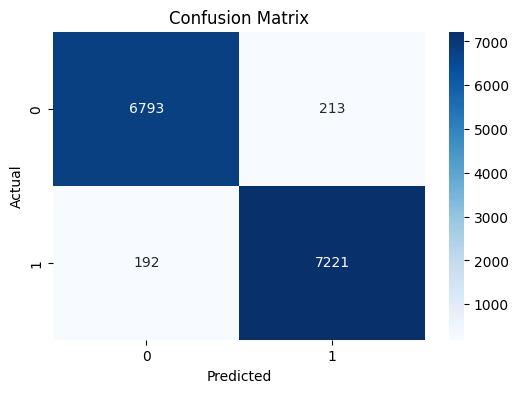

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
